# Functions

## summarize_mpf_results

In [1]:
from pathlib import Path
import json
import re
from datetime import datetime

import pandas as pd


def summarize_mpf_results(results_dir="../results"):
    """
    Summarize MPF walk-forward simulation runs.

    One row corresponds to one wf_*.json metadata file.

    Status:
        COMPLETED if the corresponding CSV exists
        RUNNING   otherwise

    Duration:
        JSON file modification time -> CSV modification time
        for completed runs, or -> current time for running runs.

    Stage 1 / Stage 2:
        Read directly from the JSON metadata:
            N_SIMULATIONS_STAGE1
            N_SIMULATIONS_STAGE2

    data_end:
        Read from END_DATE when available; otherwise inferred
        from the result CSV.
    """

    results_dir = Path(results_dir)

    rows = []

    json_files = sorted(
        results_dir.glob("wf_*.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    for json_file in json_files:

        stem = json_file.stem

        # --------------------------------------------------------
        # Parse parameters from filename
        # --------------------------------------------------------

        pattern = (
            r"^wf_(?P<strategy>.+?)"
            r"_cal(?P<cal>\d+)"
            r"_move(?P<move>\d+)"
            r"_test(?P<test>\d+)"
            r"_ncomp(?P<ncomp_start>\d+)-(?P<ncomp_end>\d+)"
        )

        match = re.search(pattern, stem)

        if match is None:
            continue

        strategy = match.group("strategy")
        cal = int(match.group("cal"))
        move = int(match.group("move"))
        test = int(match.group("test"))
        ncomp_start = int(match.group("ncomp_start"))
        ncomp_end = int(match.group("ncomp_end"))

        # --------------------------------------------------------
        # Read JSON metadata
        # --------------------------------------------------------

        try:
            with open(json_file, "r", encoding="utf-8") as f:
                meta = json.load(f)
        except Exception:
            meta = {}

        # --------------------------------------------------------
        # Corresponding result CSV
        # --------------------------------------------------------

        csv_file = results_dir / f"{stem}.csv"

        status = (
            "COMPLETED"
            if csv_file.exists()
            else "RUNNING"
        )

        # --------------------------------------------------------
        # Run date
        # --------------------------------------------------------

        timestamp_utc = meta.get("timestamp_utc")

        if timestamp_utc is not None:
            try:
                run_date = pd.to_datetime(
                    timestamp_utc,
                    format="%Y%m%d_%H%M%S",
                    utc=True,
                ).tz_localize(None)
            except Exception:
                run_date = datetime.fromtimestamp(
                    json_file.stat().st_mtime
                )
        else:
            run_date = datetime.fromtimestamp(
                json_file.stat().st_mtime
            )

        # --------------------------------------------------------
        # Duration
        # --------------------------------------------------------

        start_timestamp = json_file.stat().st_mtime

        if status == "COMPLETED":
            end_timestamp = csv_file.stat().st_mtime
        else:
            end_timestamp = datetime.now().timestamp()

        duration = str(
            pd.to_timedelta(
                max(0, end_timestamp - start_timestamp),
                unit="s",
            ).round("1s")
        )

        # --------------------------------------------------------
        # Data start
        # --------------------------------------------------------

        data_start = meta.get("START_DATE")

        # --------------------------------------------------------
        # Data end
        # --------------------------------------------------------

        data_end = meta.get("END_DATE")

        # --------------------------------------------------------
        # Stage 1 / Stage 2
        # --------------------------------------------------------

        stage1 = meta.get("N_SIMULATIONS_STAGE1")
        stage2 = meta.get("N_SIMULATIONS_STAGE2")

        # --------------------------------------------------------
        # Read result CSV
        # --------------------------------------------------------

        df = None

        if csv_file.exists():

            try:
                df = pd.read_csv(csv_file)
            except Exception:
                df = None

        # --------------------------------------------------------
        # Infer data_end from result CSV
        # --------------------------------------------------------

        if data_end is None and df is not None:

            for col in [
                "data_end",
                "end_date",
                "test_end",
                "TEST_END",
                "date",
                "Date",
            ]:

                if col in df.columns:

                    values = pd.to_datetime(
                        df[col],
                        errors="coerce",
                    ).dropna()

                    if not values.empty:
                        data_end = (
                            values.max()
                            .strftime("%Y-%m-%d")
                        )
                        break

        # --------------------------------------------------------
        # Infer data_start from result CSV if necessary
        # --------------------------------------------------------

        if data_start is None and df is not None:

            for col in [
                "data_start",
                "start_date",
                "train_start",
                "test_start",
                "TEST_START",
                "date",
                "Date",
            ]:

                if col in df.columns:

                    values = pd.to_datetime(
                        df[col],
                        errors="coerce",
                    ).dropna()

                    if not values.empty:
                        data_start = (
                            values.min()
                            .strftime("%Y-%m-%d")
                        )
                        break

        # --------------------------------------------------------
        # Ranking / selection
        # --------------------------------------------------------

        classical_ranking = (
            results_dir
            / f"{stem}_uniq_classical_ranking.csv"
        ).exists()

        idr_ranking = (
            results_dir
            / f"{stem}_uniq_idr_ranking.csv"
        ).exists()

        final_selection = (
            results_dir
            / f"{stem}_uniq_final_selection.csv"
        ).exists()

        # --------------------------------------------------------
        # Store row
        # --------------------------------------------------------

        rows.append(
            {
                "run_date": run_date,
                "status": status,
                "duration": duration,
                "strategy": strategy,
                "data_start": data_start,
                "data_end": data_end,
                "cal": cal,
                "move": move,
                "test": test,
                "ncomp_start": ncomp_start,
                "ncomp_end": ncomp_end,
                "stage1": stage1,
                "stage2": stage2,
                "classical_ranking": classical_ranking,
                "idr_ranking": idr_ranking,
                "final_selection": final_selection,
            }
        )

    # ------------------------------------------------------------
    # Create DataFrame
    # ------------------------------------------------------------

    summary = pd.DataFrame(rows)

    if summary.empty:
        return summary

    # ------------------------------------------------------------
    # Sort newest first
    # ------------------------------------------------------------

    summary["_sort_date"] = pd.to_datetime(
        summary["run_date"],
        errors="coerce",
    )

    summary = (
        summary
        .sort_values(
            "_sort_date",
            ascending=False,
        )
        .drop(columns="_sort_date")
        .reset_index(drop=True)
    )

    return summary

## extract_ranked_finalists

In [2]:
import os
import glob
import json
import pandas as pd


def extract_ranked_finalists(
    results_dir="../results",
    strategy="mean_reversion",
    data_start="2009-01-01",
    data_end="2023-12-29",
):
    """
    Extract the 8 finalist configurations for each MC2 level.

    For every MC2 level:

        Classical:
            Sharpe
            Calmar
            Return/Risk
            Robust

        IDR:
            Sharpe
            Calmar
            Return/Risk
            Robust

    The finalist is selected from the corresponding ranking file.
    Only the evaluation variables required for subsequent analysis
    are retained.

    Returns
    -------
    pandas.DataFrame
    """

    pattern = os.path.join(
        results_dir,
        f"wf_{strategy}_*.csv"
    )

    base_files = [
        f for f in glob.glob(pattern)
        if "_uniq_" not in os.path.basename(f)
    ]

    if not base_files:
        raise FileNotFoundError(
            f"No result files found for strategy '{strategy}' "
            f"in '{results_dir}'."
        )

    methods = [
        "Sharpe",
        "Calmar",
        "Return/Risk",
        "Robust",
    ]

    keep_columns = [
        "max_num_components",
        "P_positive",
        "mean_excess_return",
        "compound_excess_return",
        "sharpe_excess",
        "threshold_instability",
        "oos_instability",
        "calibration_return_mean",
        "oos_return_mean",
        "degradation",
    ]

    records = []

    for base_file in sorted(base_files):

        base_name = os.path.basename(base_file)
        base_stem = os.path.splitext(base_file)[0]

        json_file = base_stem + ".json"

        if not os.path.exists(json_file):
            continue

        with open(json_file, "r") as f:
            meta = json.load(f)

        if meta.get("STRATEGY") != strategy:
            continue

        if meta.get("START_DATE") != data_start:
            continue

        mc2 = meta.get("N_SIMULATIONS_STAGE2")

        if mc2 is None:
            continue

        # --------------------------------------------------------
        # Check requested data end
        # --------------------------------------------------------

        if data_end is not None:

            try:
                df_base = pd.read_csv(
                    base_file,
                    usecols=["test_end"]
                )

                actual_end = pd.to_datetime(
                    df_base["test_end"],
                    errors="coerce"
                ).max()

                requested_end = pd.to_datetime(data_end)

                if (
                    pd.notna(actual_end)
                    and pd.notna(requested_end)
                    and actual_end != requested_end
                ):
                    continue

            except Exception:
                continue

        # --------------------------------------------------------
        # Ranking files
        # --------------------------------------------------------

        classical_file = (
            base_stem
            + "_uniq_classical_ranking.csv"
        )

        idr_file = (
            base_stem
            + "_uniq_idr_ranking.csv"
        )

        if not os.path.exists(classical_file):
            continue

        if not os.path.exists(idr_file):
            continue

        classical = pd.read_csv(classical_file)
        idr = pd.read_csv(idr_file)

        # --------------------------------------------------------
        # Final ranking columns
        # --------------------------------------------------------

        if "classical_rank" in classical.columns:
            classical_rank_column = "classical_rank"
        elif "classical_average_rank" in classical.columns:
            classical_rank_column = "classical_average_rank"
        else:
            raise ValueError(
                "No Classical ranking column found.\n"
                f"{classical.columns.tolist()}"
            )

        if "idr_rank" in idr.columns:
            idr_rank_column = "idr_rank"
        elif "idr_average_rank" in idr.columns:
            idr_rank_column = "idr_average_rank"
        else:
            raise ValueError(
                "No IDR ranking column found.\n"
                f"{idr.columns.tolist()}"
            )

        # --------------------------------------------------------
        # Extract one finalist for each criterion
        # --------------------------------------------------------

        for ranking_type, ranking_df, rank_column in [
            ("Classical", classical, classical_rank_column),
            ("IDR", idr, idr_rank_column),
        ]:

            if "method" not in ranking_df.columns:
                raise ValueError(
                    f"'method' column missing from "
                    f"{ranking_type} ranking file."
                )

            for method in methods:

                subset = ranking_df[
                    ranking_df["method"].astype(str).str.strip()
                    == method
                ].copy()

                if subset.empty:
                    raise ValueError(
                        f"No '{method}' rows found in "
                        f"{ranking_type} ranking file."
                    )

                subset[rank_column] = pd.to_numeric(
                    subset[rank_column],
                    errors="coerce"
                )

                subset = subset.dropna(
                    subset=[rank_column]
                )

                if subset.empty:
                    raise ValueError(
                        f"No valid ranking values for "
                        f"{method} in {ranking_type}."
                    )

                finalist = subset.loc[
                    subset[rank_column].idxmin()
                ]

                # ------------------------------------------------
                # Keep only required evaluation variables
                # ------------------------------------------------

                record = {
                    "strategy": strategy,
                    "MC2": mc2,
                    "ranking_type": ranking_type,
                    "criterion": (
                        "R/R"
                        if method == "Return/Risk"
                        else method
                    ),
                    "source_file": base_name,
                }

                for column in keep_columns:

                    if column in finalist.index:
                        record[column] = finalist[column]
                    else:
                        record[column] = pd.NA

                records.append(record)

    if not records:
        raise ValueError(
            "No ranked finalists found. "
            "Check strategy, data_start and data_end."
        )

    result = pd.DataFrame(records)

    # ------------------------------------------------------------
    # Column order
    # ------------------------------------------------------------

    columns = [
        "strategy",
        "MC2",
        "ranking_type",
        "criterion",
        "max_num_components",
        "P_positive",
        "mean_excess_return",
        "compound_excess_return",
        "sharpe_excess",
        "threshold_instability",
        "oos_instability",
        "calibration_return_mean",
        "oos_return_mean",
        "degradation",
        "source_file",
    ]

    result = result[columns]

    # ------------------------------------------------------------
    # Ordering
    # ------------------------------------------------------------

    ranking_order = {
        "Classical": 0,
        "IDR": 1,
    }

    criterion_order = {
        "Sharpe": 0,
        "Calmar": 1,
        "R/R": 2,
        "Robust": 3,
    }

    result["_ranking_order"] = (
        result["ranking_type"].map(ranking_order)
    )

    result["_criterion_order"] = (
        result["criterion"].map(criterion_order)
    )

    result = (
        result
        .sort_values(
            [
                "strategy",
                "MC2",
                "_ranking_order",
                "_criterion_order",
            ]
        )
        .drop(
            columns=[
                "_ranking_order",
                "_criterion_order",
            ]
        )
        .reset_index(drop=True)
    )

    return result

## compute_M

In [3]:
import numpy as np
import pandas as pd


def compute_M(
    df,
    weights=(1.0, 1.0, 1.0, 1.0),
):
    """
    Compute robustness M-scores from robustly standardized metrics.

    Metrics
    -------
    compound_excess_return : higher is better
    degradation             : lower is better
    threshold_instability   : lower is better
    oos_instability         : lower is better

    Robust standardization:
        Z = (x - median(x)) / MAD(x)

    Composite score:
        S = alpha1 * Z_CER
            - alpha2 * Z_DD
            - alpha3 * Z_TI
            - alpha4 * Z_OI

    M-score:
        M = (1 + exp(-S))^(-1)

    The function returns three fixed pairwise M-scores:

        M_cer_dd = CER + degradation
        M_cer_ti = CER + threshold instability
        M_cer_oi = CER + OOS instability

    and one configurable four-metric score:

        M_weighted

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the four required metrics.

    weights : tuple/list of 4 floats
        Weights:
            [compound_excess_return,
             degradation,
             threshold_instability,
             oos_instability]

    Returns
    -------
    pandas.DataFrame
        Original dataframe with standardized metrics and M-scores added.
    """

    if len(weights) != 4:
        raise ValueError(
            "weights must contain exactly 4 values: "
            "[compound_excess_return, degradation, "
            "threshold_instability, oos_instability]"
        )

    alpha1, alpha2, alpha3, alpha4 = weights

    required_columns = [
        "compound_excess_return",
        "degradation",
        "threshold_instability",
        "oos_instability",
    ]

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    result = df.copy()

    # ============================================================
    # Robust standardization using median and MAD
    # ============================================================

    def robust_z(series):
        series = pd.to_numeric(
            series,
            errors="coerce"
        )

        median = series.median()

        mad = np.median(
            np.abs(
                series.dropna() - median
            )
        )

        if mad == 0 or not np.isfinite(mad):
            return pd.Series(
                0.0,
                index=series.index
            )

        return (series - median) / mad

    result["Z_compound_excess_return"] = robust_z(
        result["compound_excess_return"]
    )

    result["Z_degradation"] = robust_z(
        result["degradation"]
    )

    result["Z_threshold_instability"] = robust_z(
        result["threshold_instability"]
    )

    result["Z_oos_instability"] = robust_z(
        result["oos_instability"]
    )

    # ============================================================
    # Logistic transformation
    # ============================================================

    def logistic(score):
        return 1.0 / (
            1.0 + np.exp(-score)
        )

    # ============================================================
    # 1. Compound excess return + degradation
    # ============================================================

    S_cer_dd = (
        result["Z_compound_excess_return"]
        - result["Z_degradation"]
    )

    result["M_cer_dd"] = logistic(S_cer_dd)

    # ============================================================
    # 2. Compound excess return + threshold instability
    # ============================================================

    S_cer_ti = (
        result["Z_compound_excess_return"]
        - result["Z_threshold_instability"]
    )

    result["M_cer_ti"] = logistic(S_cer_ti)

    # ============================================================
    # 3. Compound excess return + OOS instability
    # ============================================================

    S_cer_oi = (
        result["Z_compound_excess_return"]
        - result["Z_oos_instability"]
    )

    result["M_cer_oi"] = logistic(S_cer_oi)

    # ============================================================
    # 4. Weighted four-metric M-score
    # ============================================================

    S_weighted = (
        alpha1 * result["Z_compound_excess_return"]
        - alpha2 * result["Z_degradation"]
        - alpha3 * result["Z_threshold_instability"]
        - alpha4 * result["Z_oos_instability"]
    )

    result["M_weighted"] = logistic(S_weighted)

    return result

## plot_M_bars

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch


def plot_M_bars(
    df,
    metric="M",
    filename=None,
    title=None,
	subtitle=None
):
    """
    Publication-ready black-and-white stacked bar plot.

    Encoding:
        Strategy:
            Mean Reversion = white
            Momentum       = gray

        Ranking procedure:
            Classical = solid
            IDR       = hatched (///)

        Selection method:
            Represented by bar order:
            Sharpe → Calmar → R/R → Robust

        max_num_components:
            Displayed inside the corresponding stacked segment.

    The legend is always shown.

    If filename is None, a default filename is generated
    using the strategy column and metric.
    """

    # -------------------------------------------------
    # Default filename
    # -------------------------------------------------

    if filename is None:

        strategy_values = (
            df["strategy"]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(strategy_values) == 1:
            strategy_name = strategy_values[0]
        else:
            strategy_name = "_".join(
                strategy_values
            )

        filename = (
            f"article_{strategy_name}_{metric}.pdf"
        )

    # -------------------------------------------------
    # Publication style
    # -------------------------------------------------

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

    # -------------------------------------------------
    # Required columns
    #
    # Old → new:
    #
    # stage2_simulations → MC2
    # selection_method   → ranking_type
    # method             → criterion
    # -------------------------------------------------

    required = [
        "MC2",
        "strategy",
        "ranking_type",
        "criterion",
        "max_num_components",
        metric,
    ]

    missing = [
        col
        for col in required
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    # -------------------------------------------------
    # Work on a copy
    # -------------------------------------------------

    plot_df = df[required].copy()

    plot_df["MC2"] = pd.to_numeric(
        plot_df["MC2"],
        errors="coerce",
    )

    plot_df[metric] = pd.to_numeric(
        plot_df[metric],
        errors="coerce",
    )

    plot_df["max_num_components"] = pd.to_numeric(
        plot_df["max_num_components"],
        errors="coerce",
    )

    plot_df = plot_df.dropna(
        subset=[
            "MC2",
            metric,
            "max_num_components",
        ]
    )

    # -------------------------------------------------
    # Ordering
    # -------------------------------------------------

    strategy_order = [
        "mean_reversion",
        "momentum",
    ]

    strategies = [
        s
        for s in strategy_order
        if s in plot_df["strategy"].unique()
    ]

    strategies += [
        s
        for s in sorted(plot_df["strategy"].unique())
        if s not in strategies
    ]

    method_order = [
        "Sharpe",
        "Calmar",
        "R/R",
        "Robust",
    ]

    methods = [
        m
        for m in method_order
        if m in plot_df["criterion"].unique()
    ]

    methods += [
        m
        for m in sorted(plot_df["criterion"].unique())
        if m not in methods
    ]

    sim_values = sorted(
        plot_df["MC2"].unique()
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------

    fig = plt.figure(figsize=(15.0, 5.8))

    ax = fig.add_axes([
        0.08,
        0.12,
        0.64,
        0.74,
    ])

    n_sim = len(sim_values)
    n_strategies = len(strategies)
    n_methods = len(methods)

    # -------------------------------------------------
    # Bar geometry
    # -------------------------------------------------

    group_width = 0.90

    n_bars_per_sim = (
        n_strategies * n_methods
    )

    bar_width = (
        group_width / n_bars_per_sim
    )

    x = np.arange(n_sim)

    # -------------------------------------------------
    # Strategy colors
    #
    # Mean Reversion = white
    # Momentum       = gray
    # -------------------------------------------------

    strategy_colors = {
        "mean_reversion": "1.0",
        "momentum": "0.60",
    }

    extra_strategies = [
        s
        for s in strategies
        if s not in strategy_colors
    ]

    if extra_strategies:

        shades = np.linspace(
            0.35,
            0.80,
            len(extra_strategies),
        )

        for strategy, shade in zip(
            extra_strategies,
            shades,
        ):
            strategy_colors[strategy] = str(
                shade
            )

    # -------------------------------------------------
    # Plot stacked bars
    # -------------------------------------------------

    for i, sim in enumerate(sim_values):

        sim_df = plot_df[
            plot_df["MC2"] == sim
        ]

        bar_index = 0

        for strategy in strategies:

            strategy_df = sim_df[
                sim_df["strategy"] == strategy
            ]

            strategy_color = strategy_colors[
                strategy
            ]

            # -------------------------------------------------
            # Text color
            #
            # Mean Reversion = black text
            # Momentum       = white text
            # -------------------------------------------------

            if strategy == "mean_reversion":
                text_color = "k"
            else:
                text_color = "w"

            for method in methods:

                method_df = strategy_df[
                    strategy_df["criterion"] == method
                ]

                selection_text = (
                    method_df["ranking_type"]
                    .astype(str)
                    .str.lower()
                )

                classical = method_df[
                    selection_text.str.contains(
                        "classical"
                    )
                ]

                idr = method_df[
                    ~selection_text.str.contains(
                        "classical"
                    )
                ]

                # -------------------------------------------------
                # Values
                # -------------------------------------------------

                classical_value = (
                    classical[metric].iloc[0]
                    if not classical.empty
                    else 0.0
                )

                idr_value = (
                    idr[metric].iloc[0]
                    if not idr.empty
                    else 0.0
                )

                # -------------------------------------------------
                # Components
                # -------------------------------------------------

                classical_components = (
                    classical[
                        "max_num_components"
                    ].iloc[0]
                    if not classical.empty
                    else None
                )

                idr_components = (
                    idr[
                        "max_num_components"
                    ].iloc[0]
                    if not idr.empty
                    else None
                )

                # -------------------------------------------------
                # Bar position
                # -------------------------------------------------

                offset = (
                    -group_width / 2
                    + bar_width / 2
                    + bar_index * bar_width
                )

                xpos = x[i] + offset

                # -------------------------------------------------
                # Classical segment
                # -------------------------------------------------

                ax.bar(
                    xpos,
                    classical_value,
                    width=bar_width * 0.90,
                    bottom=0,
                    color=strategy_color,
                    edgecolor="k",
                    hatch="",
                    linewidth=0.7,
                    zorder=3,
                )

                # -------------------------------------------------
                # Classical component number
                # -------------------------------------------------

                if (
                    classical_components is not None
                    and classical_value > 0
                ):
                    ax.text(
                        xpos,
                        classical_value / 2,
                        str(
                            int(
                                classical_components
                            )
                        ),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color=text_color,
                        fontweight="medium",
                        zorder=5,
                    )

                # -------------------------------------------------
                # IDR segment
                # -------------------------------------------------

                ax.bar(
                    xpos,
                    idr_value,
                    width=bar_width * 0.90,
                    bottom=classical_value,
                    color=strategy_color,
                    edgecolor="k",
                    hatch="///",
                    linewidth=0.7,
                    zorder=3,
                )

                # -------------------------------------------------
                # IDR component number
                # -------------------------------------------------

                if (
                    idr_components is not None
                    and idr_value > 0
                ):
                    ax.text(
                        xpos,
                        classical_value
                        + idr_value / 2,
                        str(
                            int(
                                idr_components
                            )
                        ),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color=text_color,
                        fontweight="medium",
                        zorder=5,
                    )

                bar_index += 1

    # -------------------------------------------------
    # X-axis
    # -------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        [
            str(int(s))
            for s in sim_values
        ]
    )

    ax.set_xlabel(
        "Number of stage-2 simulations"
    )

    # -------------------------------------------------
    # Y-axis
    # -------------------------------------------------

    ax.set_ylabel(
        metric.replace(
            "_", " "
        ).title()
    )

    # -------------------------------------------------
    # Y-axis range
    # -------------------------------------------------

    max_total = 0.0

    for sim in sim_values:

        sim_df = plot_df[
            plot_df["MC2"] == sim
        ]

        for strategy in strategies:

            strategy_df = sim_df[
                sim_df["strategy"] == strategy
            ]

            for method in methods:

                method_df = strategy_df[
                    strategy_df["criterion"] == method
                ]

                selection_text = (
                    method_df["ranking_type"]
                    .astype(str)
                    .str.lower()
                )

                classical = method_df[
                    selection_text.str.contains(
                        "classical"
                    )
                ]

                idr = method_df[
                    ~selection_text.str.contains(
                        "classical"
                    )
                ]

                classical_value = (
                    classical[metric].iloc[0]
                    if not classical.empty
                    else 0.0
                )

                idr_value = (
                    idr[metric].iloc[0]
                    if not idr.empty
                    else 0.0
                )

                max_total = max(
                    max_total,
                    classical_value
                    + idr_value,
                )

    ax.set_ylim(
        0,
        max_total * 1.15,
    )

    ax.yaxis.set_major_locator(
        mpl.ticker.MaxNLocator(6)
    )

    # -------------------------------------------------
    # Grid
    # -------------------------------------------------

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.5,
        color="0.7",
        zorder=0,
    )

    ax.set_axisbelow(True)

    # -------------------------------------------------
    # Title
    # -------------------------------------------------

    if title is None:
         title = metric.replace(
        "_", " "
        ).title()

    ax.set_title(
		title,
		fontsize=12,
		pad=18,
	)

    if subtitle is not None:
	        ax.text(
			    0.5,
			    1.01,
			    subtitle,
			    transform=ax.transAxes,
			    ha="center",
			    va="bottom",
			    fontsize=9,
		)

    # -------------------------------------------------
    # Legend 1: Ranking procedure
    #
    # Fill color = strategy
    # Hatching   = ranking procedure
    # -------------------------------------------------

    selection_handles = [
        Patch(
            facecolor="1.0",
            edgecolor="k",
            hatch="",
            label="Classical",
        ),
        Patch(
            facecolor="0.60",
            edgecolor="k",
            hatch="",
            label="",
        ),
        Patch(
            facecolor="1.0",
            edgecolor="k",
            hatch="///",
            label="Instability–Degradation",
        ),
        Patch(
            facecolor="0.60",
            edgecolor="k",
            hatch="///",
            label="",
        ),
    ]

    fig.legend(
        handles=selection_handles,
        title="Ranking procedure",
        loc="upper left",
        bbox_to_anchor=(0.73, 0.86),
        frameon=True,
        fancybox=False,
        edgecolor="k",
        borderpad=0.7,
        labelspacing=0.8,
        ncol=2,
        columnspacing=0.8,
        handletextpad=0.5,
    )

    # -------------------------------------------------
    # Legend 2: Strategy
    # -------------------------------------------------

    strategy_handles = []

    for strategy in strategies:

        label = strategy.replace(
            "_", " "
        ).title()

        strategy_handles.append(
            Patch(
                facecolor=strategy_colors[
                    strategy
                ],
                edgecolor="k",
                label=label,
            )
        )

    fig.legend(
        handles=strategy_handles,
        title="Strategy",
        loc="upper left",
        bbox_to_anchor=(0.73, 0.68),
        frameon=True,
        fancybox=False,
        edgecolor="k",
        borderpad=0.7,
        labelspacing=0.8,
    )

    # -------------------------------------------------
    # Legend 3: Selection method / bar order
    # -------------------------------------------------

    method_order_text = " → ".join(methods)

    method_handle = Patch(
        facecolor="1.0",
        edgecolor="k",
        label=method_order_text,
    )

    fig.legend(
        handles=[method_handle],
        title="Selection method (bar order)",
        loc="upper left",
        bbox_to_anchor=(0.73, 0.45),
        frameon=True,
        fancybox=False,
        edgecolor="k",
        borderpad=0.7,
        labelspacing=0.8,
        handlelength=0.0,
    )

    # -------------------------------------------------
    # Legend 4: Numbers inside bars
    # -------------------------------------------------

    component_handle = Patch(
        facecolor="1.0",
        edgecolor="k",
        label="max_num_components",
    )

    fig.legend(
        handles=[component_handle],
        title="Numbers inside bars",
        loc="upper left",
        bbox_to_anchor=(0.73, 0.25),
        frameon=True,
        fancybox=False,
        edgecolor="k",
        borderpad=0.7,
        labelspacing=0.8,
        handlelength=0.0,
    )

    # -------------------------------------------------
    # Save
    # -------------------------------------------------

    fig.savefig(
        filename,
        format="pdf",
        bbox_inches=None,
        pad_inches=0.15,
    )

    plt.close(fig)

    print(f"Saved: {filename}")

    return plot_df


## plot_compound_excess_return

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_compound_excess_return(
    df,
    filename="compound_excess_return_by_components.pdf",
    title="Compound excess return by number of components",
    figsize=(8, 5)
):
    """
    Compound the multiple OOS excess returns for each
    max_num_components and method, then plot the results.

    Methods:
        Sharpe
        Calmar
        Return/Risk
        Robust
    """

    methods = {
        "sharpe_excess_return": "Sharpe",
        "calmar_excess_return": "Calmar",
        "return_risk_excess_return": "Return/Risk",
        "robust_excess_return": "Robust",
    }

    # ------------------------------------------------------------
    # Calculate compound excess return for each method and N
    # ------------------------------------------------------------
    rows = []

    for n, group in df.groupby("max_num_components"):
        row = {"max_num_components": n}

        for column, label in methods.items():
            returns = group[column].dropna()

            # Compound the OOS excess returns
            compound_return = np.prod(1.0 + returns) - 1.0

            row[label] = compound_return

        rows.append(row)

    compound_df = (
        pd.DataFrame(rows)
        .sort_values("max_num_components")
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    colors = {
        "Sharpe": "black",
        "Calmar": "0.35",
        "Return/Risk": "0.60",
        "Robust": "0.80",
    }

    linestyles = {
        "Sharpe": "-",
        "Calmar": "--",
        "Return/Risk": "-.",
        "Robust": ":",
    }

    markers = {
        "Sharpe": "o",
        "Calmar": "s",
        "Return/Risk": "^",
        "Robust": "D",
    }

    for label in methods.values():
        ax.plot(
            compound_df["max_num_components"],
            compound_df[label],
            label=label,
            color=colors[label],
            linestyle=linestyles[label],
            marker=markers[label],
            linewidth=1.5,
            markersize=4,
        )

    # Zero reference
    ax.axhline(
        0,
        color="0.5",
        linewidth=0.8,
        linestyle="-"
    )

    ax.set_xlabel("Maximum number of components")
    ax.set_ylabel("Compound excess return")
    ax.set_title(title)

    ax.set_xticks(compound_df["max_num_components"])

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.6,
        color="0.8"
    )

    ax.legend(
        frameon=False,
        loc="best"
    )

    plt.tight_layout()

    if filename is not None:
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

    return compound_df

## plot_oos_returns_grid

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_oos_returns_grid(
    df,
    filename="oos_returns_grid.pdf",
    title="OOS returns across maximum number of components",
    ncols=2,
    figsize=None
):
    """
    Plot OOS returns as grouped bars across max_num_components.

    Each subplot represents one OOS period defined by:
        test_start -> test_end

    Bars:
        Sharpe
        Calmar
        Return/Risk
        Robust
        Index

    Parameters
    ----------
    df : pandas.DataFrame
        MPF test-results dataframe.

    filename : str or None
        Output filename. If None, the figure is not saved.

    title : str
        Overall figure title.

    ncols : int
        Number of subplot columns.

    figsize : tuple or None
        Figure size. If None, calculated automatically.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : numpy.ndarray
    """

    methods = {
        "sharpe_oos_return": "Sharpe",
        "calmar_oos_return": "Calmar",
        "return_risk_oos_return": "Return/Risk",
        "robust_oos_return": "Robust",
        "index_return": "Index",
    }

    # ------------------------------------------------------------
    # Identify OOS periods
    # ------------------------------------------------------------
    periods = (
        df[["test_start", "test_end"]]
        .drop_duplicates()
        .sort_values(["test_start", "test_end"])
        .reset_index(drop=True)
    )

    n_periods = len(periods)

    nrows = int(np.ceil(n_periods / ncols))

    if figsize is None:
        figsize = (6.5 * ncols, 4.5 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    # ------------------------------------------------------------
    # Grayscale article style
    # ------------------------------------------------------------
    colors = {
        "Sharpe": "white",
        "Calmar": "0.75",
        "Return/Risk": "0.50",
        "Robust": "0.25",
        "Index": "black",
    }

    hatches = {
        "Sharpe": "",
        "Calmar": "",
        "Return/Risk": "",
        "Robust": "",
        "Index": "//",
    }

    # ------------------------------------------------------------
    # Plot each OOS period
    # ------------------------------------------------------------
    for i, period in periods.iterrows():

        ax = axes[i]

        test_start = period["test_start"]
        test_end = period["test_end"]

        period_df = df[
            (df["test_start"] == test_start) &
            (df["test_end"] == test_end)
        ].copy()

        period_df = (
            period_df
            .sort_values("max_num_components")
            .drop_duplicates("max_num_components")
        )

        n_components = period_df["max_num_components"].to_numpy()

        x = np.arange(len(n_components))

        n_methods = len(methods)
        width = 0.8 / n_methods

        # --------------------------------------------------------
        # Grouped bars
        # --------------------------------------------------------
        for j, (column, label) in enumerate(methods.items()):

            values = period_df[column].to_numpy()

            offset = (
                j - (n_methods - 1) / 2
            ) * width

            bars = ax.bar(
                x + offset,
                values,
                width=width,
                label=label,
                color=colors[label],
                edgecolor="black",
                linewidth=0.7,
                hatch=hatches[label],
            )

        # --------------------------------------------------------
        # Zero line
        # --------------------------------------------------------
        ax.axhline(
            0,
            color="black",
            linewidth=0.8
        )

        # --------------------------------------------------------
        # Axes
        # --------------------------------------------------------
        ax.set_xticks(x)
        ax.set_xticklabels(n_components)

        ax.set_xlabel("Maximum number of components")
        ax.set_ylabel("OOS return")

        # Period title
        ax.set_title(
            f"{test_start} – {test_end}"
        )

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.6,
            color="0.8"
        )

        ax.set_axisbelow(True)

    # ------------------------------------------------------------
    # Hide unused axes
    # ------------------------------------------------------------
    for i in range(n_periods, len(axes)):
        axes[i].set_visible(False)

    # ------------------------------------------------------------
    # One common legend
    # ------------------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=len(methods),
        frameon=False
    )

    fig.suptitle(
        title,
        y=1.02
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    if filename is not None:
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

    return fig, axes

## plot_mean_oos_returns_mr_momentum

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_mean_oos_returns_mr_momentum(
    df_mr,
    df_momentum,
    filename="mean_oos_returns_mr_momentum.pdf",
    title="Mean OOS return across maximum number of components",
    ncols=2,
    figsize=None
):
    """
    Plot mean OOS returns for Mean Reversion and Momentum.

    For each OOS period (test_start -> test_end), the plot shows:

        y = mean(
            sharpe_oos_return,
            calmar_oos_return,
            return_risk_oos_return,
            robust_oos_return
        )

    across max_num_components.

    The index_return is shown as a horizontal reference line
    in each subplot.

    Parameters
    ----------
    df_mr : pandas.DataFrame
        Mean-reversion test results.

    df_momentum : pandas.DataFrame
        Momentum test results.

    filename : str or None
        Output filename. If None, the figure is not saved.

    title : str
        Overall figure title.

    ncols : int
        Number of subplot columns.

    figsize : tuple or None
        Figure size. Automatically determined if None.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : numpy.ndarray
    """

    # ------------------------------------------------------------
    # OOS return columns
    # ------------------------------------------------------------
    return_columns = [
        "sharpe_oos_return",
        "calmar_oos_return",
        "return_risk_oos_return",
        "robust_oos_return",
    ]

    # ------------------------------------------------------------
    # Calculate mean OOS return for each dataframe
    # ------------------------------------------------------------
    def prepare_dataframe(df):

        data = df.copy()

        data["mean_oos_return"] = data[
            return_columns
        ].mean(axis=1)

        return data

    mr = prepare_dataframe(df_mr)
    momentum = prepare_dataframe(df_momentum)

    # ------------------------------------------------------------
    # Identify OOS periods
    # ------------------------------------------------------------
    periods_mr = mr[
        ["test_start", "test_end"]
    ].drop_duplicates()

    periods_momentum = momentum[
        ["test_start", "test_end"]
    ].drop_duplicates()

    periods = pd.concat(
        [periods_mr, periods_momentum]
    ).drop_duplicates()

    periods = (
        periods
        .sort_values(["test_start", "test_end"])
        .reset_index(drop=True)
    )

    n_periods = len(periods)

    # ------------------------------------------------------------
    # Grid dimensions
    # ------------------------------------------------------------
    nrows = int(np.ceil(n_periods / ncols))

    if figsize is None:
        figsize = (
            6.5 * ncols,
            4.0 * nrows
        )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False
    )

    axes = axes.flatten()

    # ------------------------------------------------------------
    # Plot each OOS period
    # ------------------------------------------------------------
    for i, period in periods.iterrows():

        ax = axes[i]

        test_start = period["test_start"]
        test_end = period["test_end"]

        # --------------------------------------------------------
        # Mean Reversion
        # --------------------------------------------------------
        mr_period = mr[
            (mr["test_start"] == test_start) &
            (mr["test_end"] == test_end)
        ].copy()

        mr_period = (
            mr_period
            .groupby("max_num_components", as_index=False)
            .agg(
                mean_oos_return=("mean_oos_return", "mean"),
                index_return=("index_return", "mean")
            )
            .sort_values("max_num_components")
        )

        # --------------------------------------------------------
        # Momentum
        # --------------------------------------------------------
        momentum_period = momentum[
            (momentum["test_start"] == test_start) &
            (momentum["test_end"] == test_end)
        ].copy()

        momentum_period = (
            momentum_period
            .groupby("max_num_components", as_index=False)
            .agg(
                mean_oos_return=("mean_oos_return", "mean"),
                index_return=("index_return", "mean")
            )
            .sort_values("max_num_components")
        )

        # --------------------------------------------------------
        # Mean Reversion line
        # --------------------------------------------------------
        ax.plot(
            mr_period["max_num_components"],
            mr_period["mean_oos_return"],
            color="black",
            linestyle="-",
            marker="o",
            linewidth=1.5,
            markersize=4,
            label="Mean Reversion"
        )

        # --------------------------------------------------------
        # Momentum line
        # --------------------------------------------------------
        ax.plot(
            momentum_period["max_num_components"],
            momentum_period["mean_oos_return"],
            color="0.45",
            linestyle="--",
            marker="s",
            linewidth=1.5,
            markersize=4,
            label="Momentum"
        )

        # --------------------------------------------------------
        # Index return
        #
        # Same index return for the OOS period, so use the
        # average across available rows.
        # --------------------------------------------------------
        index_values = pd.concat(
            [
                mr_period["index_return"],
                momentum_period["index_return"]
            ]
        ).dropna()

        if len(index_values) > 0:

            index_return = index_values.mean()

            ax.axhline(
                index_return,
                color="0.25",
                linestyle=":",
                linewidth=1.2
            )

            # Put index return on the right-hand side
            ax.text(
                1.01,
                index_return,
                f"Index: {index_return:.3f}",
                transform=ax.get_yaxis_transform(),
                va="center",
                ha="left",
                fontsize=9,
                color="0.25"
            )

        # --------------------------------------------------------
        # Zero line
        # --------------------------------------------------------
        ax.axhline(
            0,
            color="black",
            linewidth=0.7
        )

        # --------------------------------------------------------
        # Subplot title
        # --------------------------------------------------------
        ax.set_title(
            f"{test_start} – {test_end}"
        )

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.6,
            color="0.8"
        )

        ax.set_axisbelow(True)

    # ------------------------------------------------------------
    # Hide unused axes
    # ------------------------------------------------------------
    for i in range(n_periods, len(axes)):
        axes[i].set_visible(False)

    # ------------------------------------------------------------
    # Common axis labels
    # ------------------------------------------------------------
    fig.supxlabel(
        "Maximum number of components"
    )

    fig.supylabel(
        "Mean OOS return"
    )

    # ------------------------------------------------------------
    # Common legend
    # ------------------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=2,
        frameon=False
    )

    fig.suptitle(
        title,
        y=1.04
    )

    plt.tight_layout(
        rect=[0.03, 0.03, 1, 0.93]
    )

    if filename is not None:
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

    return fig, axes

### plot_mean_oos_returns_mr_momentum

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_mean_oos_returns_mr_momentum(
    df_mr,
    df_momentum,
    filename="mean_oos_returns_mr_momentum.pdf",
    title="Mean OOS return across maximum number of components",
    figsize=None
):
    return_columns = [
        "sharpe_oos_return",
        "calmar_oos_return",
        "return_risk_oos_return",
        "robust_oos_return",
    ]

    def prepare_dataframe(df):
        data = df.copy()
        data["mean_oos_return"] = data[return_columns].mean(axis=1)
        return data

    mr = prepare_dataframe(df_mr)
    momentum = prepare_dataframe(df_momentum)

    periods = (
        pd.concat([
            mr[["test_start", "test_end"]],
            momentum[["test_start", "test_end"]]
        ])
        .drop_duplicates()
        .sort_values(["test_start", "test_end"])
        .reset_index(drop=True)
    )

    n_periods = len(periods)

    if figsize is None:
        figsize = (8, 2.5 * n_periods)

    fig, axes = plt.subplots(
        n_periods,
        1,
        figsize=figsize,
        sharex=True,
        sharey=True,
        gridspec_kw={"hspace": 0.05}
    )

    if n_periods == 1:
        axes = [axes]

    # ------------------------------------------------------------
    # Common y-axis limits
    # ------------------------------------------------------------
    all_mean_returns = pd.concat([
        mr["mean_oos_return"],
        momentum["mean_oos_return"]
    ]).dropna()

    all_index_returns = pd.concat([
        mr["index_return"],
        momentum["index_return"]
    ]).dropna()

    y_values = pd.concat([
        all_mean_returns,
        all_index_returns
    ])

    y_min = y_values.min()
    y_max = y_values.max()

    margin = 0.08 * (y_max - y_min)

    if margin == 0:
        margin = 0.01

    y_min -= margin
    y_max += margin

    # ------------------------------------------------------------
    # Plot each OOS period
    # ------------------------------------------------------------
    for i, period in periods.iterrows():

        ax = axes[i]

        test_start = period["test_start"]
        test_end = period["test_end"]

        mr_period = mr[
            (mr["test_start"] == test_start) &
            (mr["test_end"] == test_end)
        ].copy()

        momentum_period = momentum[
            (momentum["test_start"] == test_start) &
            (momentum["test_end"] == test_end)
        ].copy()

        mr_period = (
            mr_period
            .groupby("max_num_components", as_index=False)
            .agg(
                mean_oos_return=("mean_oos_return", "mean"),
                index_return=("index_return", "mean")
            )
            .sort_values("max_num_components")
        )

        momentum_period = (
            momentum_period
            .groupby("max_num_components", as_index=False)
            .agg(
                mean_oos_return=("mean_oos_return", "mean"),
                index_return=("index_return", "mean")
            )
            .sort_values("max_num_components")
        )

        # --------------------------------------------------------
        # Mean Reversion
        # --------------------------------------------------------
        ax.plot(
            mr_period["max_num_components"],
            mr_period["mean_oos_return"],
            color="black",
            linestyle="-",
            marker="o",
            linewidth=1.4,
            markersize=3.5,
            label="Mean Reversion"
        )

        # --------------------------------------------------------
        # Momentum
        # --------------------------------------------------------
        ax.plot(
            momentum_period["max_num_components"],
            momentum_period["mean_oos_return"],
            color="0.45",
            linestyle="--",
            marker="s",
            linewidth=1.4,
            markersize=3.5,
            label="Momentum"
        )

        # --------------------------------------------------------
        # Index return
        # --------------------------------------------------------
        index_values = pd.concat([
            mr_period["index_return"],
            momentum_period["index_return"]
        ]).dropna()

        if len(index_values) > 0:

            index_return = index_values.mean()

            # Horizontal index-return reference line
            ax.axhline(
                index_return,
                color="0.30",
                linewidth=1.0,
                linestyle=":",
                zorder=1
            )

            # Index return label on the far right
            ax.text(
                1.01,
                index_return,
                f"Index {index_return:.3f}",
                transform=ax.get_yaxis_transform(),
                ha="left",
                va="center",
                fontsize=8,
                color="0.30",
                clip_on=False
            )

        # --------------------------------------------------------
        # Zero line
        # --------------------------------------------------------
        ax.axhline(
            0,
            color="0.65",
            linewidth=0.6,
            linestyle="-"
        )

        # --------------------------------------------------------
        # Period label
        # --------------------------------------------------------
        ax.text(
            0.01,
            0.92,
            f"{test_start} – {test_end}",
            transform=ax.transAxes,
            fontsize=9,
            ha="left",
            va="top"
        )

        # --------------------------------------------------------
        # Common limits
        # --------------------------------------------------------
        ax.set_ylim(y_min, y_max)

        # --------------------------------------------------------
        # Grid
        # --------------------------------------------------------
        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.5,
            color="0.85"
        )

        ax.set_axisbelow(True)

        # --------------------------------------------------------
        # Remove subplot boxes
        # --------------------------------------------------------
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if i < n_periods - 1:
            ax.spines["bottom"].set_visible(False)
            ax.tick_params(
                axis="x",
                bottom=False,
                labelbottom=False
            )

    # ------------------------------------------------------------
    # Common x-axis
    # ------------------------------------------------------------
    all_components = sorted(
        set(mr["max_num_components"])
        | set(momentum["max_num_components"])
    )

    axes[-1].set_xticks(all_components)
    axes[-1].set_xlabel("Maximum number of components")

    # ------------------------------------------------------------
    # Common y-axis
    # ------------------------------------------------------------
    fig.supylabel(
        "Mean OOS return",
        x=0.02
    )

    # ------------------------------------------------------------
    # Common legend
    # ------------------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    # Add index line to legend
    index_handle = mpl.lines.Line2D(
        [],
        [],
        color="0.30",
        linestyle=":",
        linewidth=1.0,
        label="Index return"
    )

    handles.append(index_handle)
    labels.append("Index return")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        frameon=False
    )

    fig.suptitle(
        title,
        y=1.035
    )

    plt.subplots_adjust(
        left=0.10,
        right=0.88,
        bottom=0.08,
        top=0.92,
        hspace=0.04
    )

    if filename is not None:
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

    return fig, axes

## summarize_by_index_return

In [23]:
def summarize_by_index_return(df_mr, df_momentum):
    return_columns = [
        "sharpe_oos_return",
        "calmar_oos_return",
        "return_risk_oos_return",
        "robust_oos_return",
    ]

    def prepare(df, prefix):
        data = df.copy()

        # Mean across the four methods
        data["mean_oos_return"] = data[return_columns].mean(axis=1)

        summary = (
            data.groupby(
                ["test_start", "test_end"],
                as_index=False
            )
            .agg(
                index_return=("index_return", "mean"),
                mean=("mean_oos_return", "mean"),
                median=("mean_oos_return", "median"),
                sd=("mean_oos_return", "std")
            )
        )

        summary = summary.rename(columns={
            "mean": f"{prefix}_mean",
            "median": f"{prefix}_median",
            "sd": f"{prefix}_sd"
        })

        return summary

    mr = prepare(df_mr, "mean_reversion")
    momentum = prepare(df_momentum, "momentum")

    # Merge the two strategies by OOS period
    summary = pd.merge(
        mr,
        momentum,
        on=["test_start", "test_end"],
        suffixes=("", "_momentum")
    )

    # Keep one common index return
    summary["index_return"] = (
        summary["index_return"]
        + summary["index_return_momentum"]
    ) / 2

    summary["period"] = (
        summary["test_start"].astype(str)
        + " – "
        + summary["test_end"].astype(str)
    )

    summary = summary.sort_values(
        "index_return"
    ).reset_index(drop=True)

    summary = summary[
        [
            "period",
            "index_return",
            "mean_reversion_mean",
            "mean_reversion_median",
            "mean_reversion_sd",
            "momentum_mean",
            "momentum_median",
            "momentum_sd"
        ]
    ]

    return summary

# Idea

In [ ]:
# Execution order in MPF folder

# 1. python scripts/run_walk_forward_optimization.py

# 2. python scripts/evaluate_train_results.py 

<table>
  <tr>
    <th>Workflow</th>
    <th>Train</th>
    <th>Test</th>
  </tr>
  <tr>
    <td>1. <code>run_walk_forward_optimization.py</code></td>
    <td><b>Step 1</b><br>N2_sim ∈ {100, 250, 500, 1000, 1500}<br>for all {q, n_max_components}</td>
    <td><b>Step 3</b><br>Apply N2_sim* for<br>{q*, n_max_components*} from Step 2</td>
  </tr>
  <tr>
    <td>2. <code>evaluate_train_results.py</code></td>
    <td><b>Step 2</b><br>4 best Classic + 4 best IDR</td>
    <td><b>Step 4</b><br>Compare results vs Step 2</td>
  </tr>
</table>

In [ ]:
                 MC2 = 100
                       │
        ┌──────────────┴──────────────┐
        │                             │
   Classical                         IDR
        │                             │
   ┌────┼────┬────┐             ┌────┼────┬────┐
 Sharpe Calmar R/R Robust      Sharpe Calmar R/R Robust
   │      │     │     │           │      │     │     │
 best    best  best  best        best   best  best  best

# Research

## Simulations overview

In [6]:
summary = summarize_mpf_results()
summary

,run_date,status,duration,strategy,data_start,data_end,cal,move,test,ncomp_start,ncomp_end,stage1,stage2,classical_ranking,idr_ranking,final_selection
0,2026-09-22 15:10:55,COMPLETED,0 days 19:51:57,momentum,2018-01-01,2026-08-28,6,12,12,5,20,500,1000,False,False,False
1,2026-09-22 09:52:40,COMPLETED,0 days 04:17:37,mean_reversion,2018-01-01,2026-08-28,6,12,12,5,20,500,1000,False,False,False
2,2026-09-17 09:57:25,COMPLETED,1 days 04:28:45,momentum,2009-01-01,2023-12-29,6,12,12,5,20,500,1500,True,True,True
3,2026-09-15 15:41:00,COMPLETED,1 days 15:58:30,momentum,2009-01-01,2023-12-29,6,12,12,5,20,500,1000,True,True,True
4,2026-09-15 07:01:09,COMPLETED,0 days 07:35:38,momentum,2009-01-01,2023-12-29,6,12,12,5,20,500,500,True,True,True
5,2026-09-14 13:37:48,COMPLETED,0 days 17:06:29,momentum,2009-01-01,2023-12-29,6,12,12,5,20,500,250,True,True,True
6,2026-09-14 07:12:45,COMPLETED,0 days 04:07:02,momentum,2009-01-01,2023-12-29,6,12,12,5,20,500,100,True,True,True
7,2026-09-09 14:05:52,COMPLETED,1 days 22:26:22,mean_reversion,2009-01-01,2023-12-29,6,12,12,5,20,500,1500,True,True,True
8,2026-09-08 07:00:59,COMPLETED,1 days 06:58:02,mean_reversion,2009-01-01,2023-12-29,6,12,12,5,20,500,1000,True,True,True
9,2026-09-07 06:20:54,COMPLETED,1 days 00:09:47,mean_reversion,2009-01-01,2023-12-29,6,12,12,5,20,500,500,True,True,True


## Train / hyperparam

## Trade off

In [5]:
df_mr = extract_ranked_finalists(
    results_dir="../results",
    strategy="mean_reversion",
    data_start="2009-01-01",
    data_end="2023-12-29"
    
)

df_mm = extract_ranked_finalists(
    results_dir="../results",
    strategy="momentum",
    data_start="2009-01-01",
    data_end="2023-12-29"
    
)

df = pd.concat([df_mr, df_mm], ignore_index=True)

In [12]:
# compound_excess_return, degradation, threshold_instability, oos_instability

weights = (0, 0, 0, 1)

weights_str = "_".join(
    f"{w:g}".replace(".", "")
    for w in weights
)

filename = f"performance_trade_off_{weights_str}.pdf"

df = compute_M(
    df,
    weights=weights,
)

plot_M_bars(
    df,
    metric="M_weighted",
    filename=filename,
    title="Performance–Stability Trade-off",
    subtitle=(
        f"Weighted composite measure "
        f"({weights[0]:.1f}, {weights[1]:.1f}, "
        f"{weights[2]:.1f}, {weights[3]:.1f})"
    ),
)

Saved: performance_trade_off_0_0_0_1.pdf


,MC2,strategy,ranking_type,criterion,max_num_components,M_weighted
0,100,mean_reversion,Classical,Sharpe,15,0.449058
1,100,mean_reversion,Classical,Calmar,15,0.462519
2,100,mean_reversion,Classical,R/R,15,0.449058
3,100,mean_reversion,Classical,Robust,10,0.954537
4,100,mean_reversion,IDR,Sharpe,8,0.823989
...,...,...,...,...,...,...
75,1500,momentum,Classical,Robust,6,0.432189
76,1500,momentum,IDR,Sharpe,20,0.453033
77,1500,momentum,IDR,Calmar,12,0.291787
78,1500,momentum,IDR,R/R,14,0.296301


## Distribution

In [13]:
# https://grok.com/c/6dce84e4-218c-48d4-9911-15c21df20fa3?rid=92abf2b2-e1fe-48b4-9240-dbad6f20eb83

In [6]:
sim_mm_1500 = pd.read_csv("../results/wf_momentum_cal6_move12_test12_ncomp5-20_20260917_095725_82ce0368f4f1.csv")

In [7]:
sim_mm_1500.columns

Index(['max_num_components', 'calibration_start', 'calibration_end',
       'test_start', 'test_end', 'stage1_robust_buy_thr',
       'stage1_robust_sell_thr', 'stage1_top10_buy_std',
       'stage1_top10_sell_std', 'stage2_buy_min', 'stage2_buy_max',
       'stage2_sell_min', 'stage2_sell_max', 'sharpe_buy_thr',
       'sharpe_sell_thr', 'sharpe_calibration', 'sharpe_calibration_return',
       'sharpe_oos_return', 'sharpe_excess_return', 'calmar_buy_thr',
       'calmar_sell_thr', 'calmar_calibration', 'calmar_calibration_return',
       'calmar_oos_return', 'calmar_excess_return', 'return_risk_buy_thr',
       'return_risk_sell_thr', 'return_risk_calibration',
       'return_risk_calibration_return', 'return_risk_oos_return',
       'return_risk_excess_return', 'robust_buy_thr', 'robust_sell_thr',
       'robust_calibration_sharpe', 'robust_calibration_return',
       'robust_calibration_calmar', 'robust_calibration_return_risk',
       'robust_oos_return', 'robust_excess_return', '

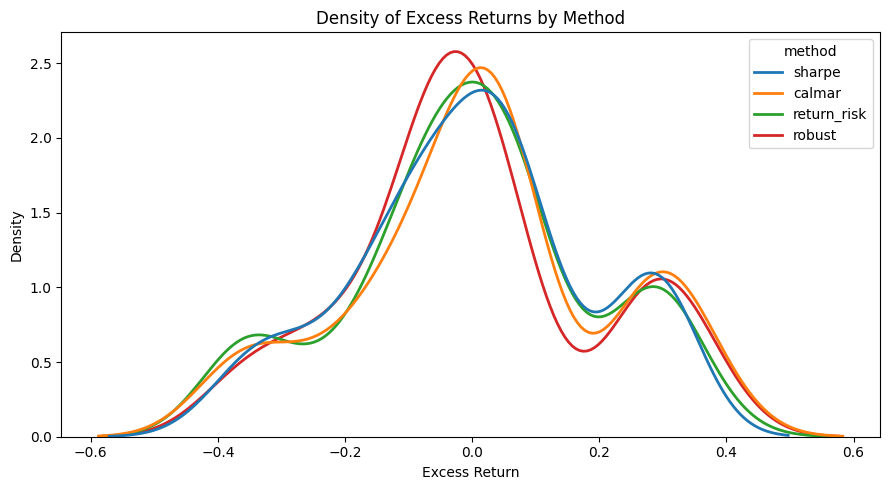

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select all *_excess_return columns
cols = [c for c in sim_mm_1500.columns if c.endswith("_excess_return")]

# Convert to long format
df_density = sim_mm_1500[cols].melt(
    var_name="metric",
    value_name="excess_return"
)

# Extract the part before "_excess_return"
df_density["method"] = df_density["metric"].str.replace(
    "_excess_return", "", regex=False
)

# Density plot
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=df_density,
    x="excess_return",
    hue="method",
    fill=False,
    common_norm=False,
    linewidth=2
)

plt.xlabel("Excess Return")
plt.ylabel("Density")
plt.title("Density of Excess Returns by Method")
plt.tight_layout()
plt.show()

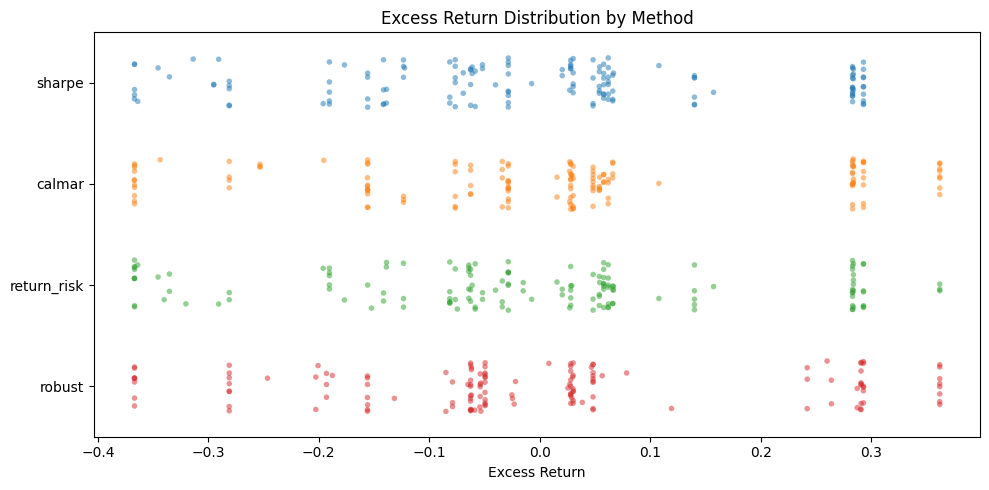

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select all *_excess_return columns
cols = [c for c in sim_mm_1500.columns if c.endswith("_excess_return")]

# Convert to long format
df_density = sim_mm_1500[cols].melt(
    var_name="metric",
    value_name="excess_return"
)

# Extract the part before "_excess_return"
df_density["method"] = df_density["metric"].str.replace(
    "_excess_return", "", regex=False
)

plt.figure(figsize=(10, 5))

sns.stripplot(
    data=df_density,
    x="excess_return",
    y="method",
    hue="method",
    jitter=0.25,
    alpha=0.5,
    size=4,
    legend=False
)

plt.xlabel("Excess Return")
plt.ylabel("")
plt.title("Excess Return Distribution by Method")
plt.tight_layout()
plt.show()

## Excess return

In [9]:
# Final decision; to use 1000 sim; convergence

df_train_1000_mr = pd.read_csv("../results/wf_mean_reversion_cal6_move12_test12_ncomp5-20_20260908_070059_e6c330fed31e.csv")

df_train_1000_mm = pd.read_csv("../results/wf_momentum_cal6_move12_test12_ncomp5-20_20260915_154100_ba035fc972cc.csv")

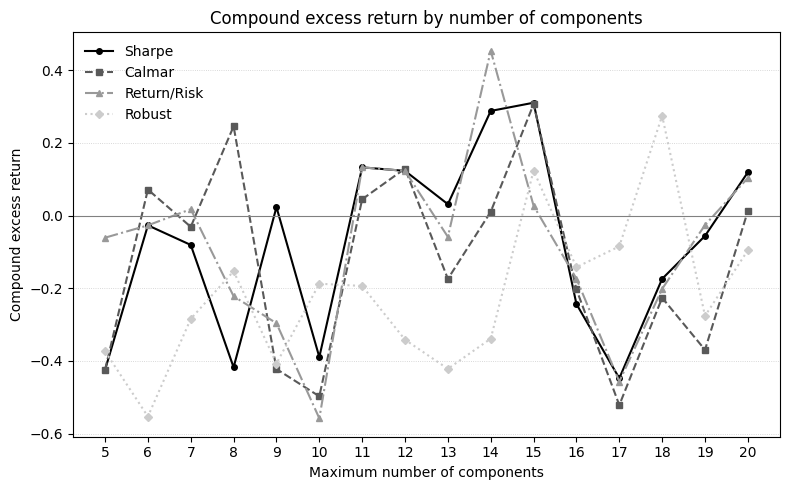

In [7]:
compound_train_1000_mr = plot_compound_excess_return(
    df_train_1000_mr,
    filename="compound_excess_return_train_1000_mr.pdf"
)

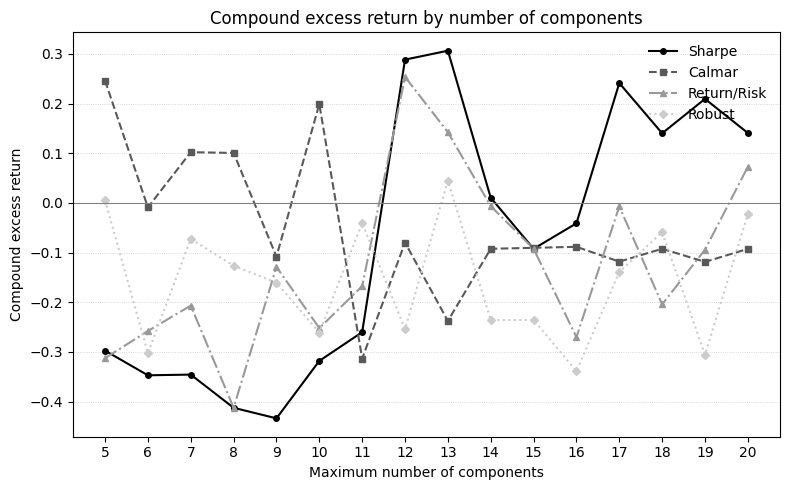

In [8]:
compound_train_1000_mm = plot_compound_excess_return(
    df_train_1000_mm,
    filename="compound_excess_return_train_1000_mm.pdf"
)

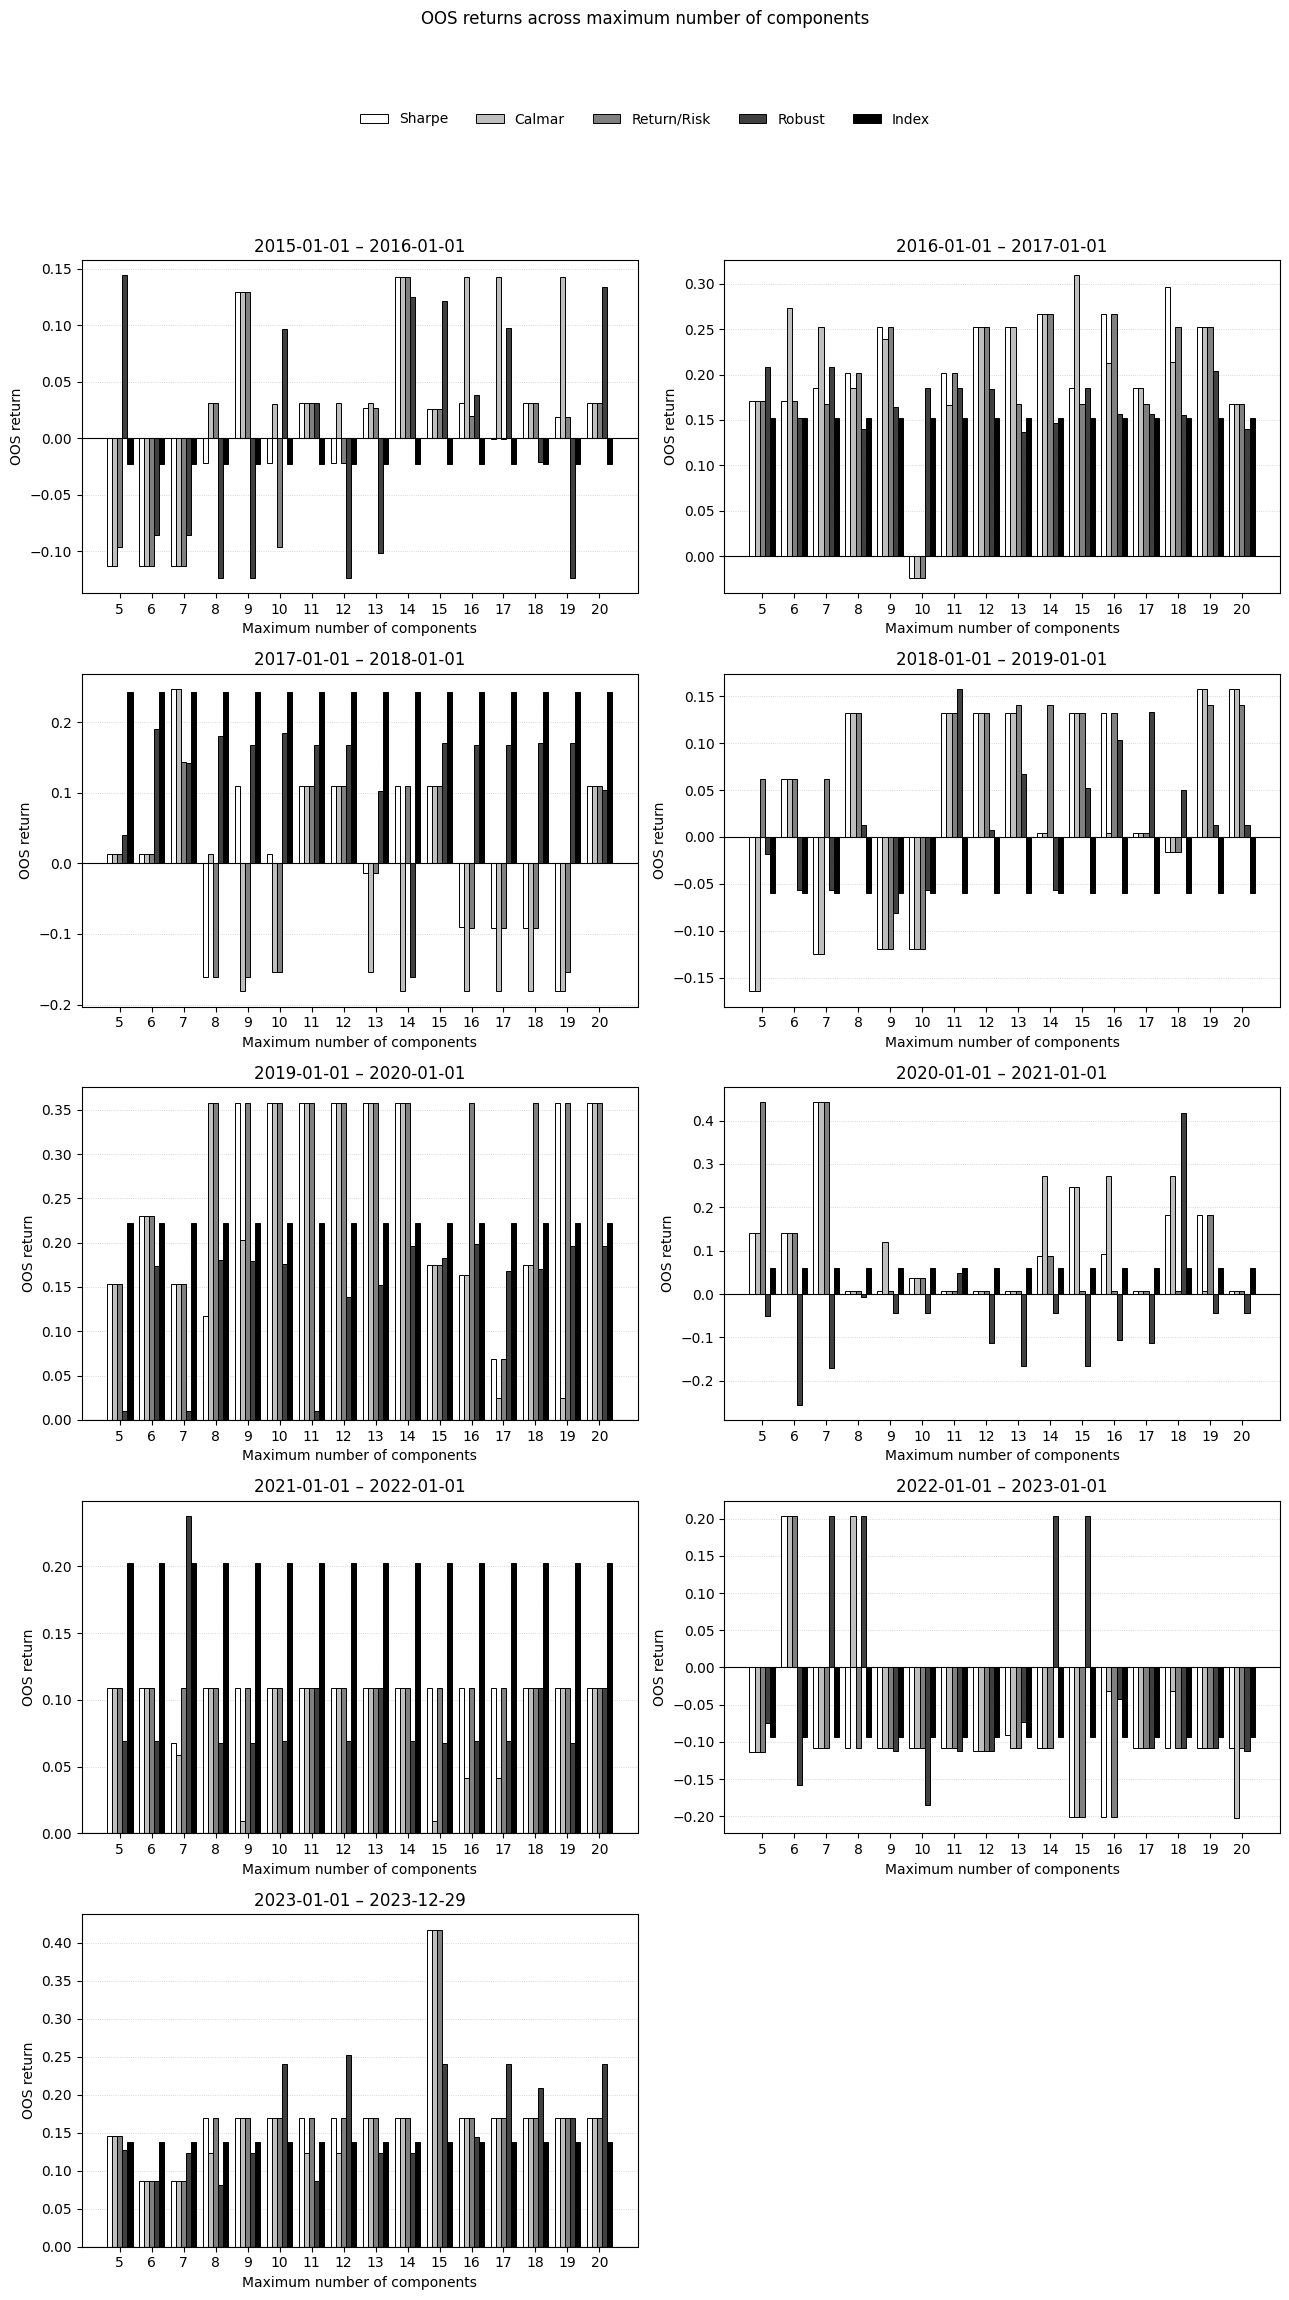

In [12]:
fig, axes = plot_oos_returns_grid(
    df_train_1000_mr,
    filename="oos_returns_grid_1000_mr.pdf"
)

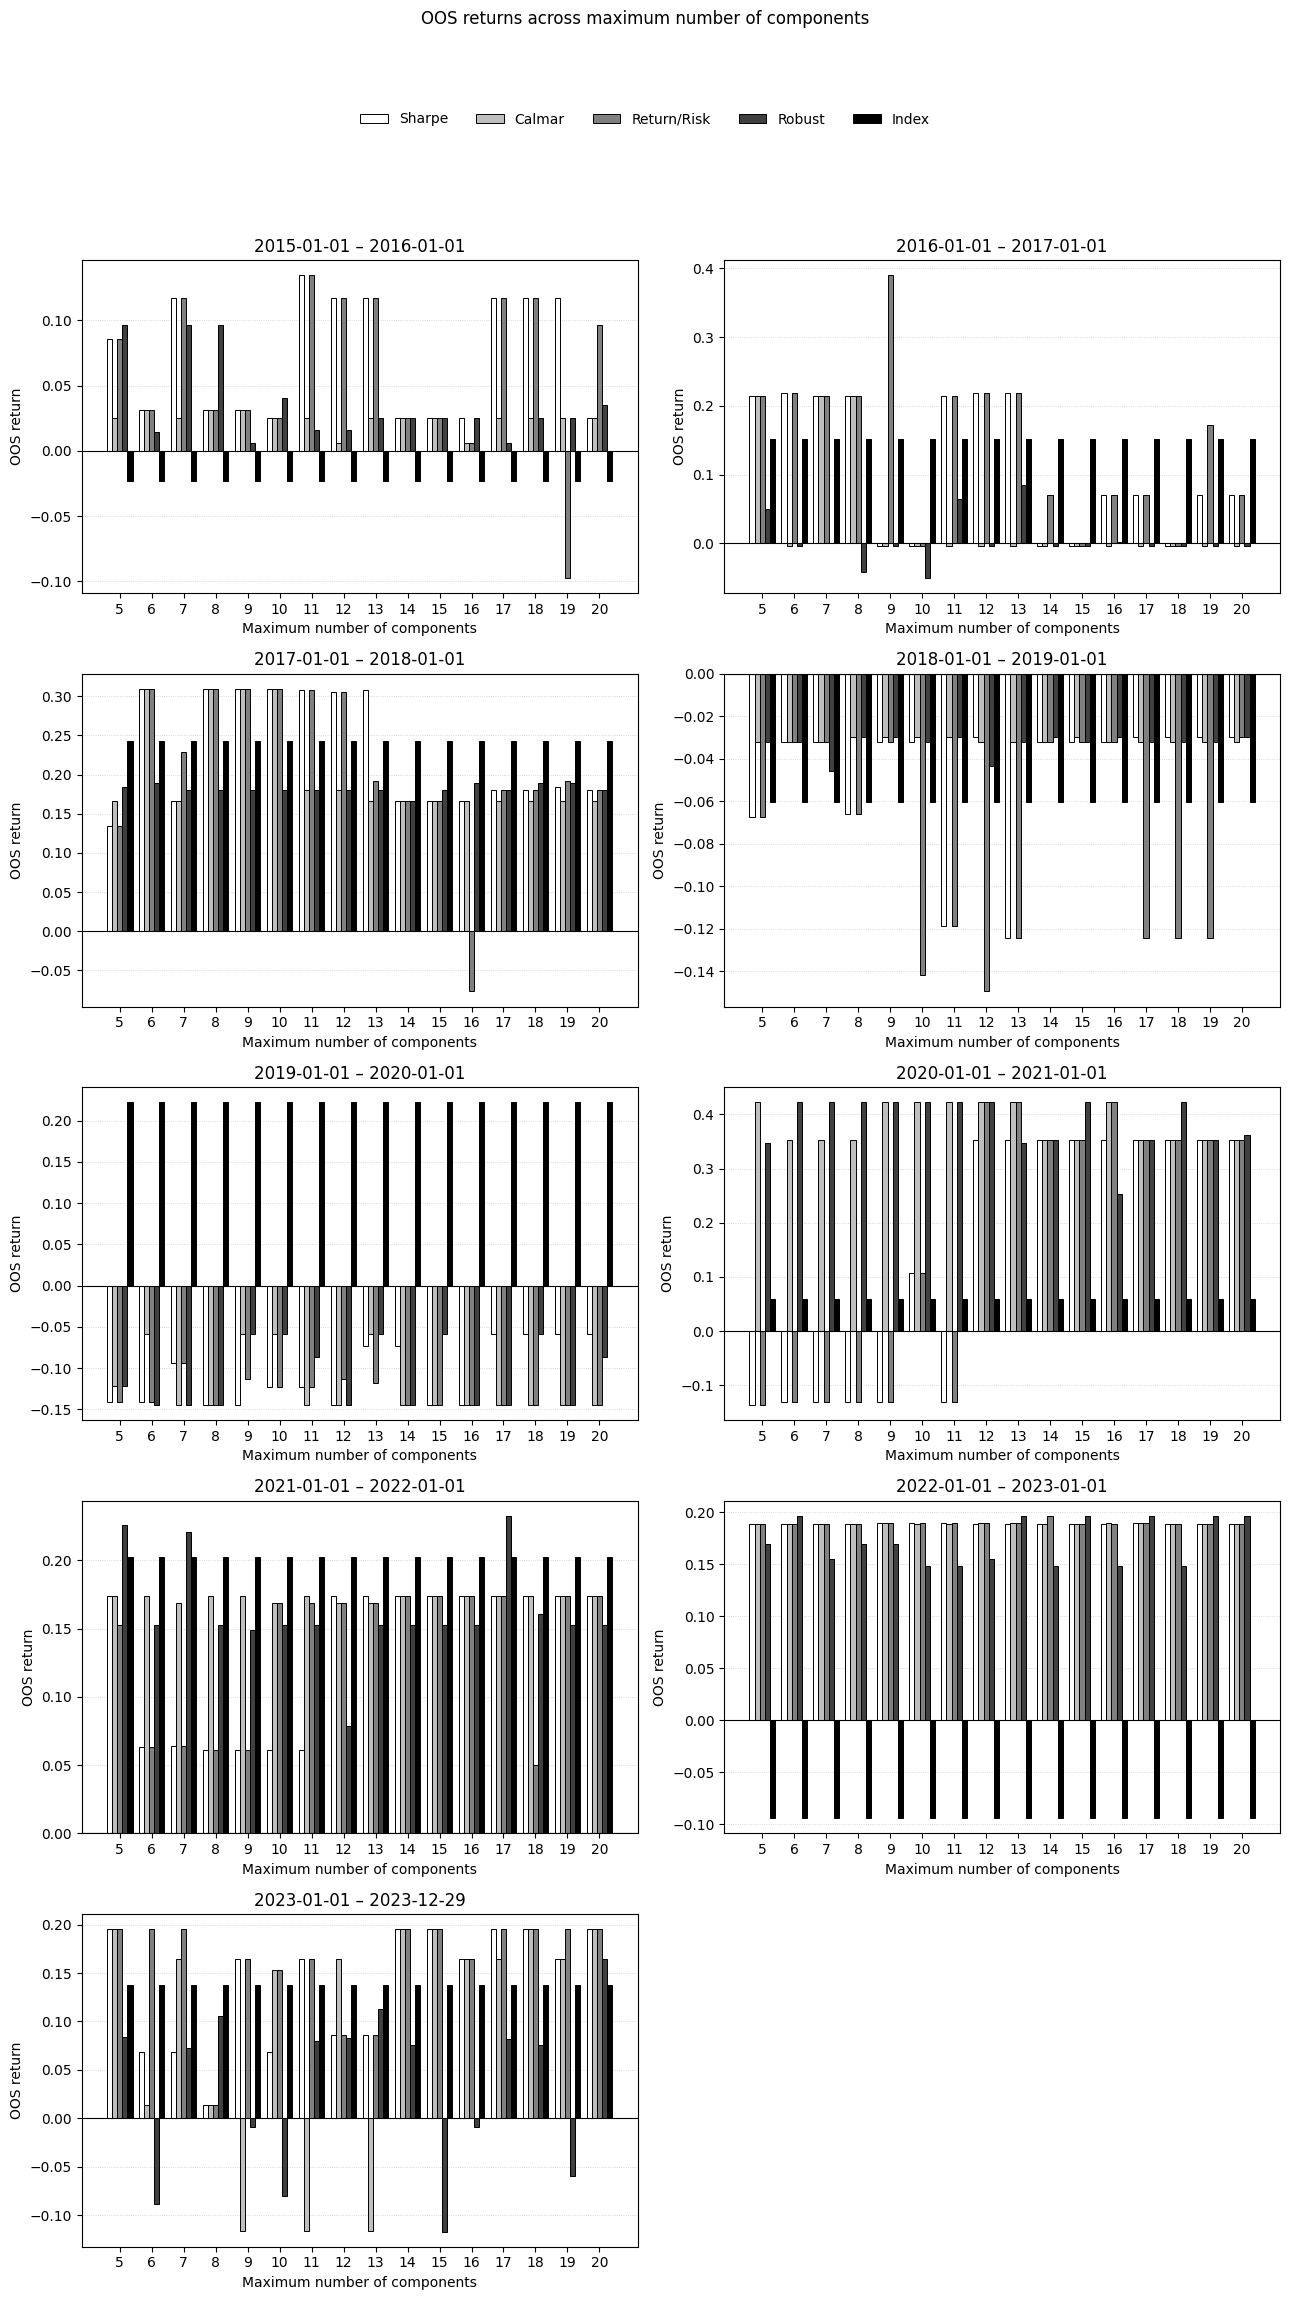

In [13]:
fig, axes = plot_oos_returns_grid(
    df_train_1000_mm,
    filename="oos_returns_grid_1000_mm.pdf"
)

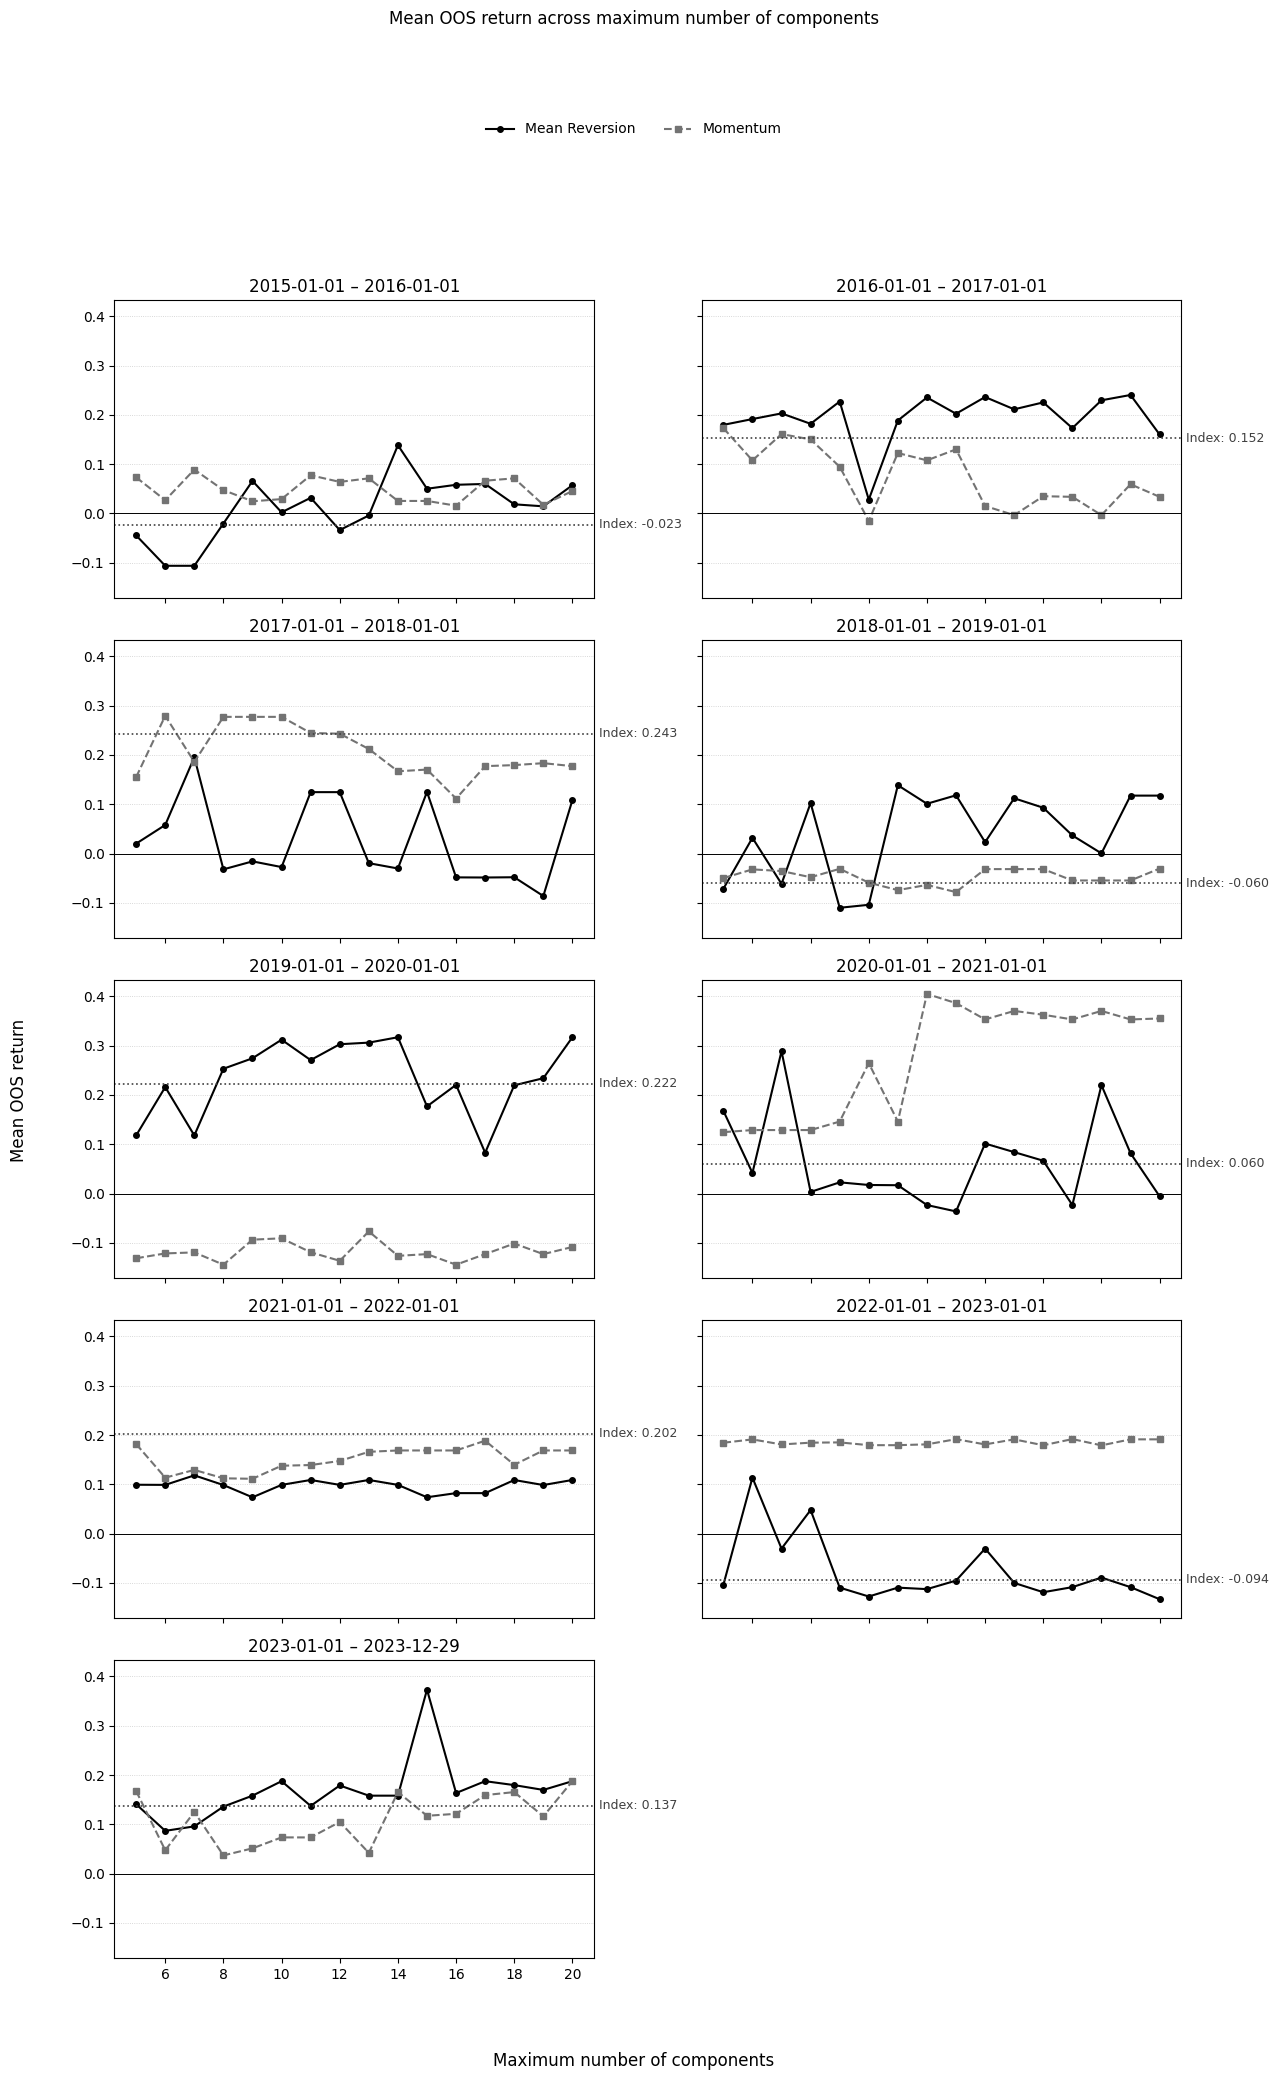

In [16]:
fig, axes = plot_mean_oos_returns_mr_momentum(
    df_train_1000_mr,
    df_train_1000_mm,
    filename="mean_oos_returns_mr_momentum.pdf"
)

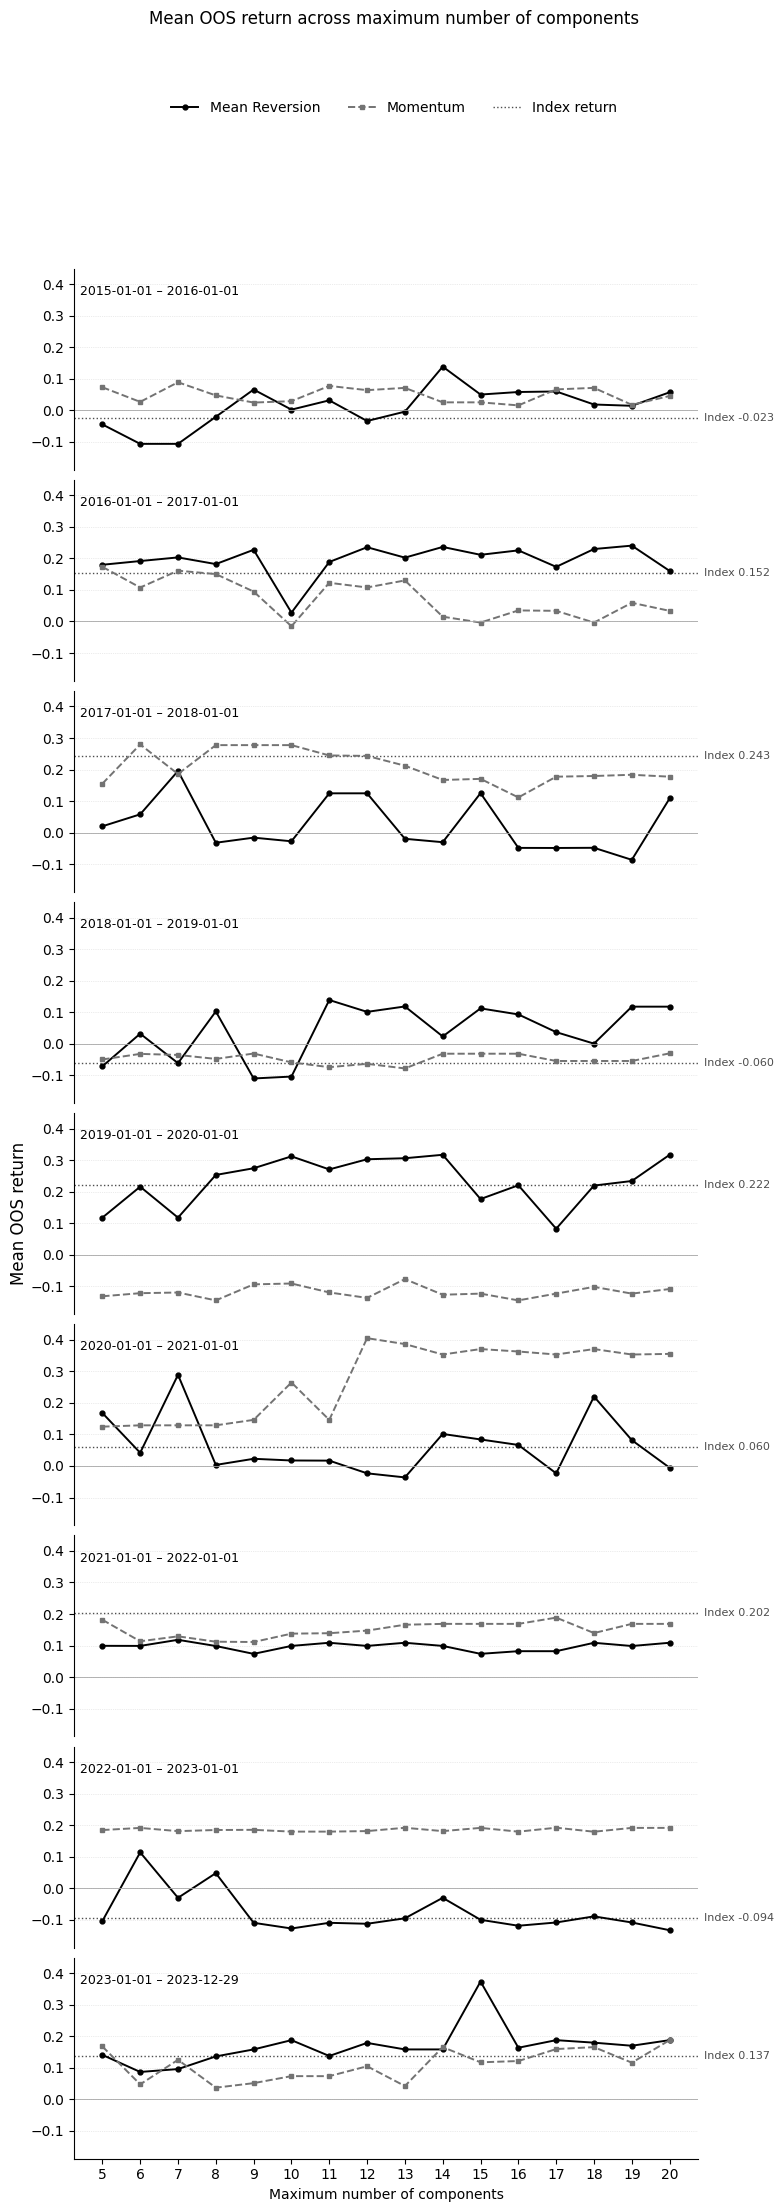

In [29]:
fig, axes = plot_mean_oos_returns_mr_momentum(
    df_train_1000_mr,
    df_train_1000_mm,
    filename="mean_oos_returns_mr_momentum.pdf"
)

In [26]:
df_index_summary = summarize_by_index_return(
    df_train_1000_mr,
    df_train_1000_mm,
)

df_index_summary

,period,index_return,mean_reversion_mean,mean_reversion_median,mean_reversion_sd,momentum_mean,momentum_median,momentum_sd
0,2022-01-01 – 2023-01-01,-0.093968,-0.076134,-0.106413,0.068730,0.185101,0.184396,0.005313
1,2018-01-01 – 2019-01-01,-0.060286,0.040296,0.064813,0.086182,-0.047617,-0.048993,0.016160
2,2015-01-01 – 2016-01-01,-0.022877,0.011441,0.016587,0.064256,0.048227,0.046507,0.024774
3,2020-01-01 – 2021-01-01,0.060192,0.064019,0.032266,0.092472,0.273644,0.353289,0.115519
4,2023-01-01 – 2023-12-29,0.137407,0.168673,0.160824,0.062364,0.109663,0.116741,0.050593
5,2016-01-01 – 2017-01-01,0.152409,0.194715,0.202778,0.050957,0.075209,0.077089,0.063140
6,2021-01-01 – 2022-01-01,0.202304,0.097240,0.098803,0.013058,0.150560,0.156632,0.025253
7,2019-01-01 – 2020-01-01,0.222400,0.233764,0.243676,0.076193,-0.117680,-0.122208,0.019080
8,2017-01-01 – 2018-01-01,0.243312,0.024939,-0.017767,0.084947,0.207397,0.184543,0.052356


In [35]:
df_index_summary.mean(numeric_only=True)

index_return             0.093433
mean_reversion_mean      0.084328
mean_reversion_median    0.077285
mean_reversion_sd        0.066573
momentum_mean            0.098278
momentum_median          0.105333
momentum_sd              0.041354
dtype: float64

In [31]:
df_index_summary["index_return"].corr(df_index_summary["mean_reversion_mean"])

np.float64(0.6726724488864974)

In [32]:
df_index_summary["index_return"].corr(df_index_summary["momentum_mean"])

np.float64(-0.004071319225110963)

## Test

In [27]:
# Load test results

df_test_1000_mr = pd.read_csv("../results/wf_mean_reversion_cal6_move12_test12_ncomp5-20_20260922_095240_357ae5a8e72e.csv")

df_test_1000_mm = pd.read_csv("../results/wf_momentum_cal6_move12_test12_ncomp5-20_20260922_151055_a4d97c766333.csv")

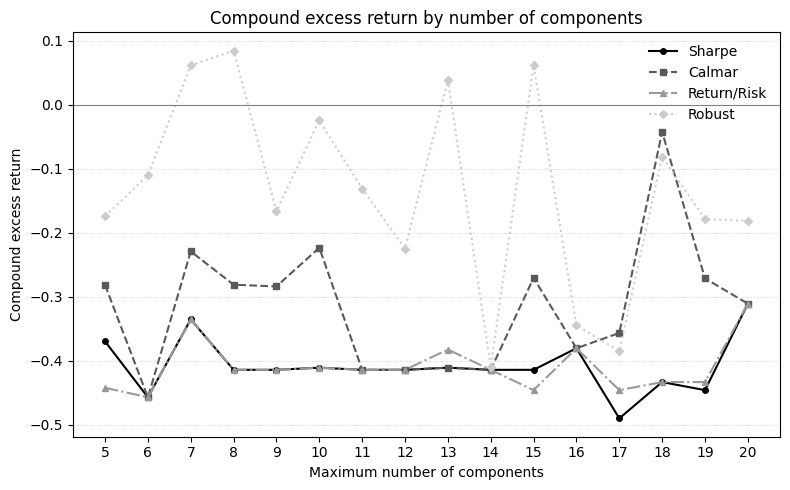

In [9]:
compound_test_1000_mr = plot_compound_excess_return(
    df_test_1000_mr,
    filename="compound_excess_return_test_1000_mr.pdf"
)

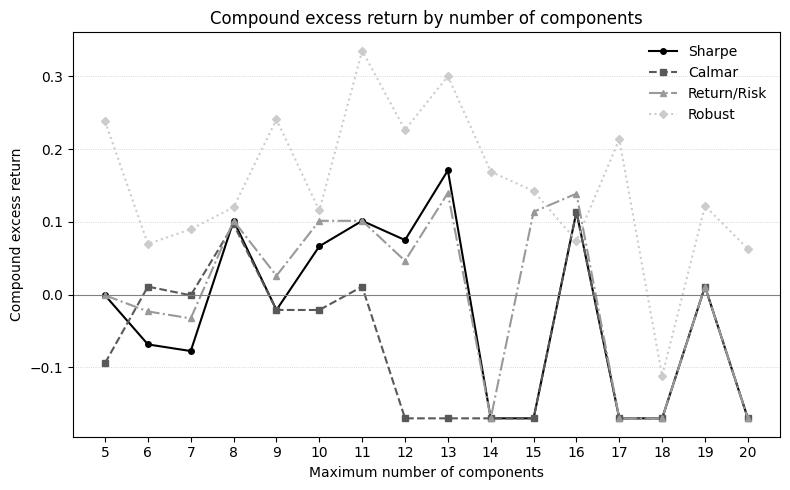

In [10]:
compound_test_1000_mm = plot_compound_excess_return(
    df_test_1000_mm,
    filename="compound_excess_return_test_1000_mm.pdf"
)

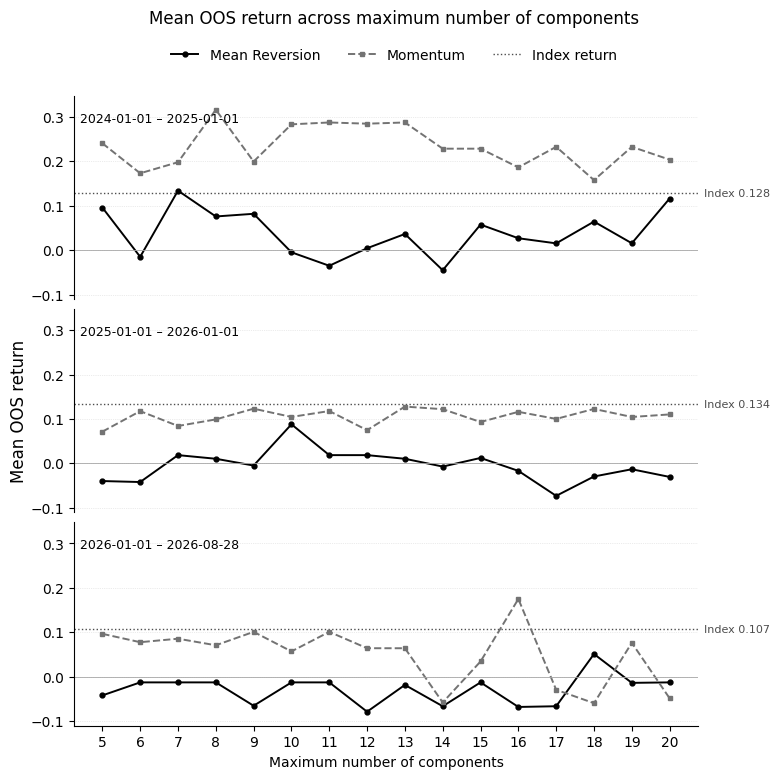

In [30]:
fig, axes = plot_mean_oos_returns_mr_momentum(
    df_test_1000_mr,
    df_test_1000_mm,
    filename="mean_oos_returns_mr_momentum_test.pdf"
)